# Pseudotemporal Ordering in Adult Human Bone Marrow

This notebook follows the pseudotemporal ordering workflow from **Single-Cell Best Practices**. It constructs **Diffusion Pseudotime (DPT)** for an adult human bone-marrow dataset and compares it with a pre-computed **Palantir pseudotime**.

The notebook keeps the executed outputs and figures so the complete analysis is visible directly on GitHub.


## 1. Environment setup

The analysis uses Scanpy for preprocessing, diffusion maps, and DPT.


In [1]:
import scanpy as sc

## 2. Data loading

The dataset contains **5,780 cells and 27,876 genes**. If the local file is not present, Scanpy downloads the dataset once using the provided backup URL.


In [2]:
adata = sc.read(
    "data/pseudotemporal.h5ad",
    backup_url="https://ndownloader.figshare.com/files/35826944",
)

adata

AnnData object with n_obs × n_vars = 5780 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced'

## 3. Preprocessing

Genes with very low total counts are filtered, followed by library-size normalization, log transformation, highly-variable-gene annotation, PCA, and nearest-neighbor graph construction.


In [3]:
sc.pp.filter_genes(adata, min_counts=20)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)

sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=10)

## 4. Cell-type structure

The pre-computed t-SNE embedding is colored by cell-type annotation to visualize the organization of the bone-marrow populations.


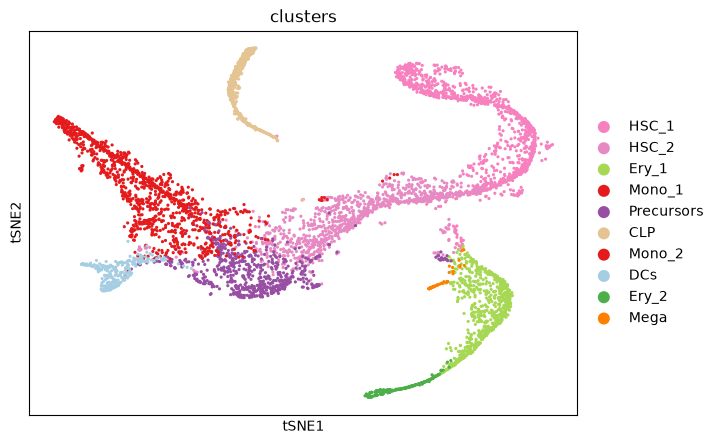

In [4]:
sc.pl.scatter(
    adata,
    basis="tsne",
    color="clusters",
)

## 5. Diffusion map

DPT operates on diffusion geometry, so a diffusion map is computed from the neighborhood graph.


In [5]:
sc.tl.diffmap(adata)

## 6. Root-cell selection

The developmental process is known to begin in hematopoietic stem cells. A putative root cell is therefore selected from an extreme value of the fourth stored diffusion component (`X_diffmap[:, 3]`), following the chapter workflow.


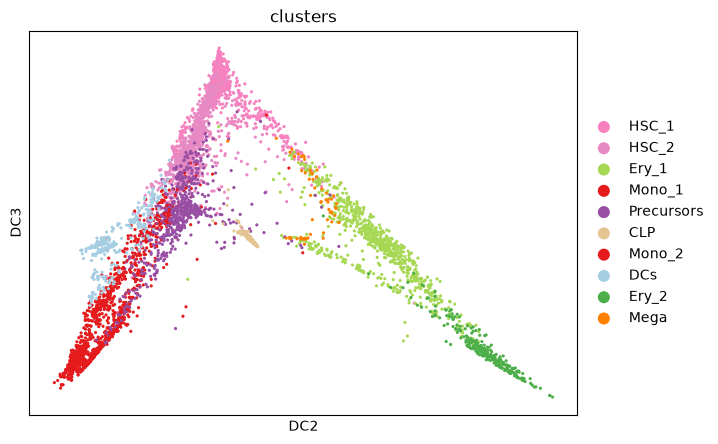

In [6]:
# Setting root cell as described above
root_ixs = adata.obsm["X_diffmap"][:, 3].argmin()

sc.pl.scatter(
    adata,
    basis="diffmap",
    color=["clusters"],
    components=[2, 3],
)

adata.uns["iroot"] = root_ixs

## 7. Diffusion Pseudotime

DPT assigns each cell a relative developmental position with respect to the selected root cell.


In [7]:
sc.tl.dpt(adata)

## 8. DPT versus Palantir

The newly computed DPT values are compared with the Palantir pseudotime already included in the dataset.


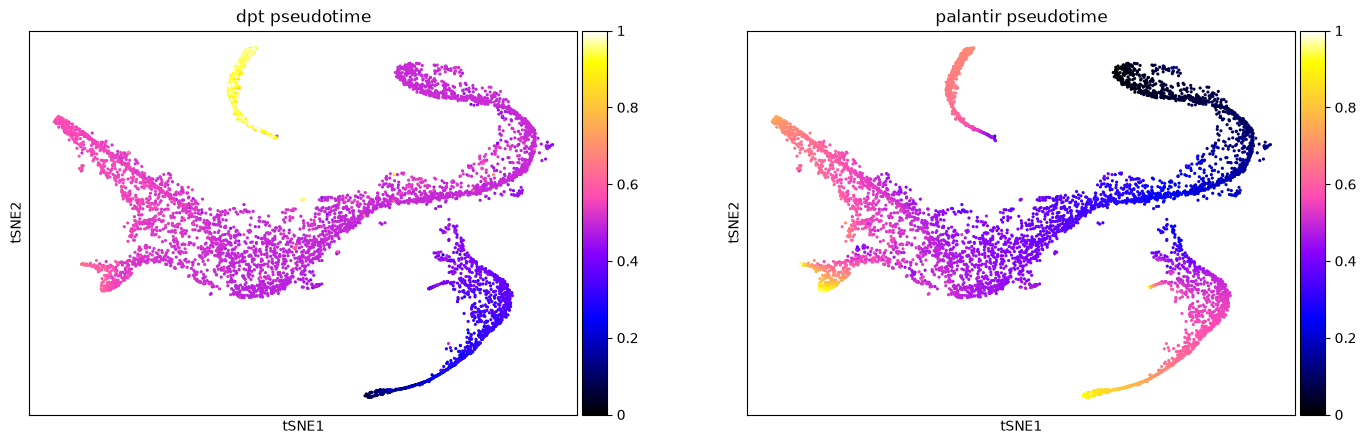

In [8]:
sc.pl.scatter(
    adata,
    basis="tsne",
    color=["dpt_pseudotime", "palantir_pseudotime"],
    color_map="gnuplot2",
)

## 9. Pseudotime distributions across cell types

Violin plots make it easier to compare the distributions of both pseudotime estimates across annotated cell populations.


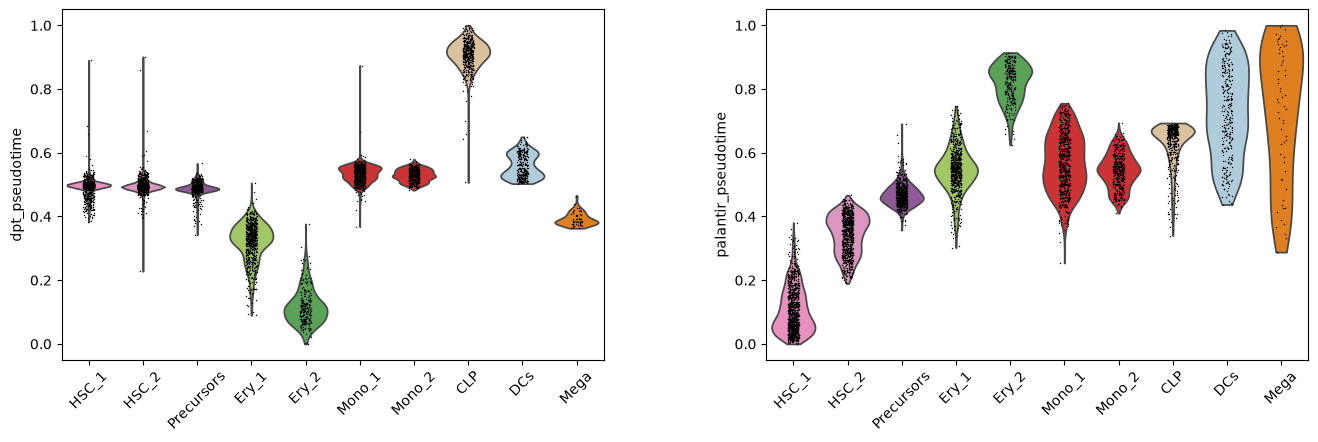

In [9]:
sc.pl.violin(
    adata,
    keys=["dpt_pseudotime", "palantir_pseudotime"],
    groupby="clusters",
    rotation=45,
    order=[
        "HSC_1",
        "HSC_2",
        "Precursors",
        "Ery_1",
        "Ery_2",
        "Mono_1",
        "Mono_2",
        "CLP",
        "DCs",
        "Mega",
    ],
)

## Conclusion

For this dataset, DPT assigns unusually high pseudotime values to the **CLP** population and also elevated values to some **HSC_1/HSC_2** cells. The Palantir pseudotime shows a progression that is more consistent with the known developmental hierarchy of adult bone marrow. Accordingly, the chapter recommends continuing with the Palantir pseudotime.
